# Final Assignment: Part 1 — Create Visualizations using Matplotlib, Seaborn & Folium

**Project:** Analyzing the Impact of Recession on Automobile Sales

This notebook covers the nine visualization criteria in the assignment, plus the separate vehicle-type trend visualization from Task 1.2. Every chart cell is executed and its output is embedded in this notebook. The course dataset is included beside the notebook so it can be rerun in an environment where local files are supported.

**Important for grading:** keep this notebook as an `.ipynb` file and upload the notebook itself for Question 1. The code and rendered output for each chart are intentionally in distinct cells with task labels.

## 0. Load the course dataset and required libraries

The notebook prefers the supplied `historical_automobile_sales.csv`. If the file is not present in the working directory, it falls back to the IBM Skills Network dataset URL. It handles the two column-name variants for unemployment rate (`unemployment_rate` and `Unemployment_Rate`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA_URL = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/"
    "historical_automobile_sales.csv"
)
try:
    df = pd.read_csv("historical_automobile_sales.csv")
except FileNotFoundError:
    df = pd.read_csv(DATA_URL)

if "Year" not in df.columns:
    df["Year"] = pd.to_datetime(df["Date"]).dt.year
if "Month" not in df.columns:
    df["Month"] = pd.to_datetime(df["Date"]).dt.strftime("%b")
if "unemployment_rate" not in df.columns and "Unemployment_Rate" in df.columns:
    df["unemployment_rate"] = df["Unemployment_Rate"]
if "Unemployment_Rate" not in df.columns and "unemployment_rate" in df.columns:
    df["Unemployment_Rate"] = df["unemployment_rate"]

UNEMPLOYMENT_COL = "unemployment_rate" if "unemployment_rate" in df.columns else "Unemployment_Rate"
MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
df["Month"] = df["Month"].astype(str).str[:3]
df["Month"] = pd.Categorical(df["Month"], categories=MONTH_ORDER, ordered=True)
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print(f"Rows: {len(df):,}")
print(f"Years: {int(df['Year'].min())}–{int(df['Year'].max())}")
print(f"Columns: {list(df.columns)}")
display(df.head())

Rows: 2,640
Years: 1980–2023
Columns: ['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence', 'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition', 'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales', 'Vehicle_Type', 'City', 'Unemployment_Rate']


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City,Unemployment_Rate
0,1/31/1980,1980,Jan,1,99.38,0.9,32958.26,2.424046e+07,31.88,14026.18,2.18,6.14,527.88,ExecutiveCar,City_1,6.14
1,1/31/1980,1980,Jan,1,99.38,0.9,25317.56,1.862390e+08,31.88,14026.18,3.28,6.14,1435.58,MediumFamilyCar,City_1,6.14
2,1/31/1980,1980,Jan,1,99.38,0.9,19901.79,1.043567e+08,31.88,14026.18,1.64,6.14,1615.05,SmallFamilyCar,City_1,6.14
3,1/31/1980,1980,Jan,1,99.38,0.9,30232.89,1.461730e+08,31.88,14026.18,2.45,6.14,758.98,Sports,City_1,6.14
4,1/31/1980,1980,Jan,1,99.38,0.9,14955.26,2.496301e+08,31.88,14026.18,2.35,6.14,1725.28,SuperMiniCar,City_1,6.14


## Task 1.1 — Average Annual Automobile Sales Fluctuations from Year to Year

The mean `Automobile_Sales` value is grouped by `Year` and plotted using Pandas' line-plot functionality.

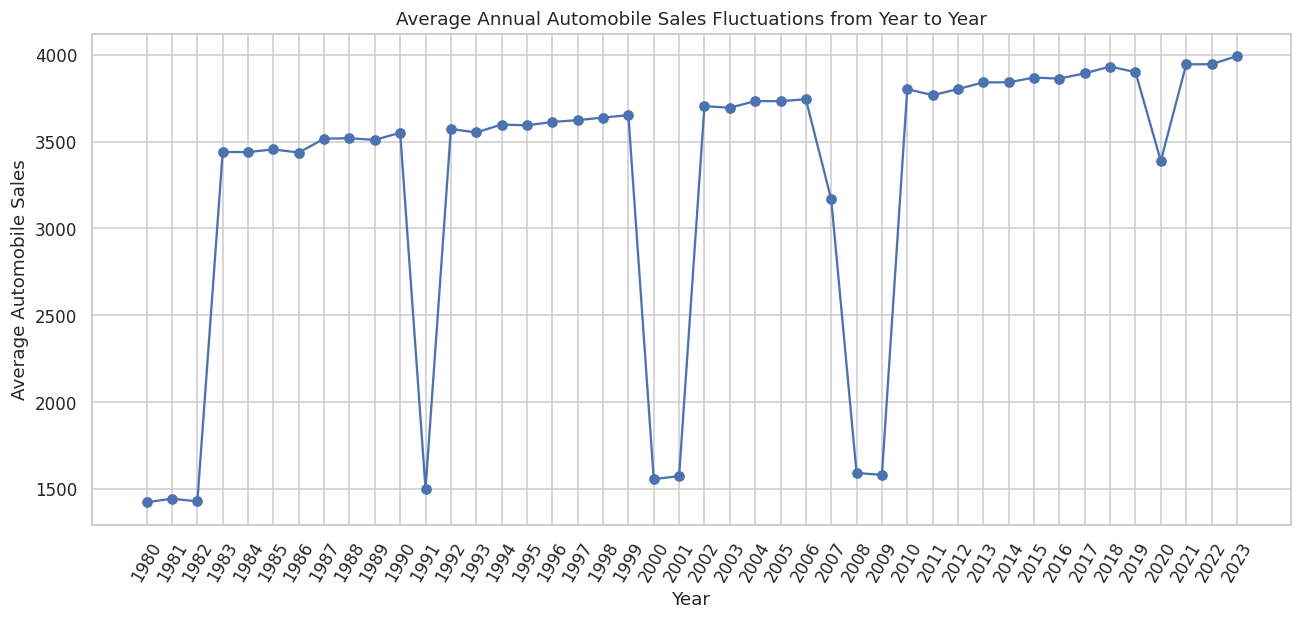

In [2]:
# Task 1.1: Show how Average Annual Automobile Sales fluctuate from year to year.
df_line = df.groupby(df["Year"])["Automobile_Sales"].mean()
plt.figure(figsize=(12, 5.8))
df_line.plot(kind="line", marker="o")
plt.xlabel("Year")
plt.ylabel("Average Automobile Sales")
plt.title("Average Annual Automobile Sales Fluctuations from Year to Year")
plt.xticks(sorted(df["Year"].dropna().astype(int).unique()), rotation=60)
plt.tight_layout()
plt.savefig("Line_Plot_1.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 1.2 — Vehicle-Type Sales Trends During Recession Periods

This line chart restricts the data to recession observations and plots each vehicle category as a separate line by year.

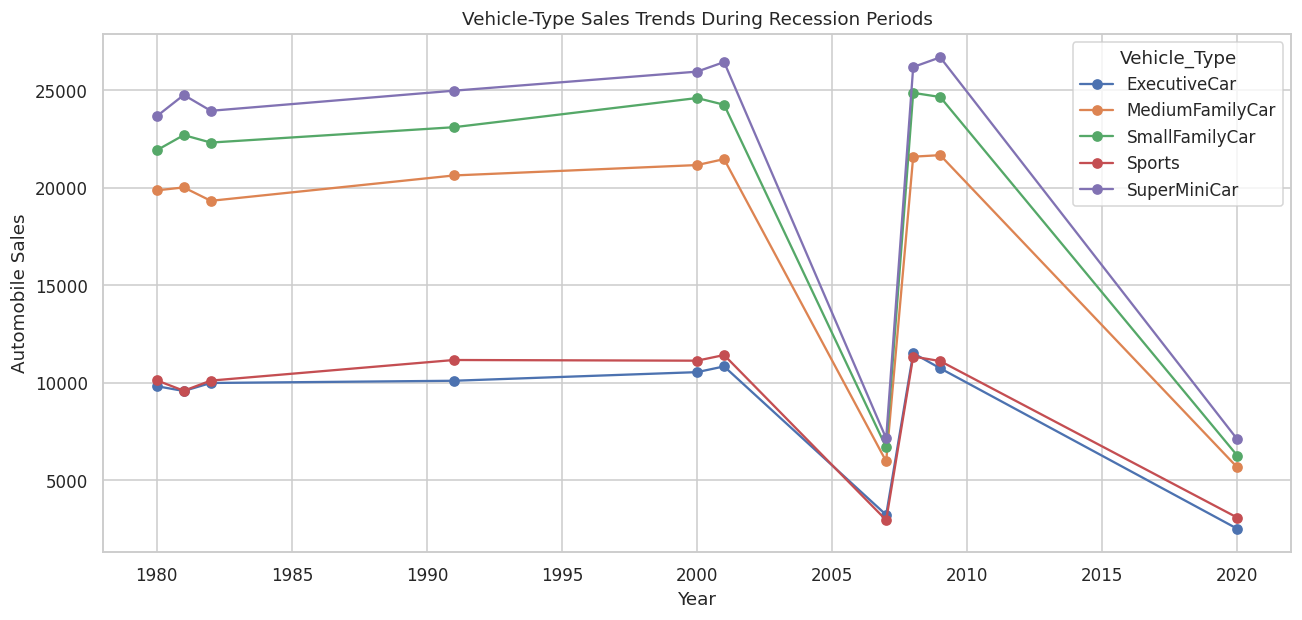

In [3]:
recession_data = df[df["Recession"] == 1].copy()
df_Mline = (
    recession_data.groupby(["Year", "Vehicle_Type"], as_index=False, observed=True)["Automobile_Sales"]
    .sum()
)
df_Mline = df_Mline.pivot(index="Year", columns="Vehicle_Type", values="Automobile_Sales")
ax = df_Mline.plot(kind="line", figsize=(12, 5.8), marker="o")
ax.set_xlabel("Year")
ax.set_ylabel("Automobile Sales")
ax.set_title("Vehicle-Type Sales Trends During Recession Periods")
plt.tight_layout()
plt.savefig("Line_Plot_2.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 1.2 — Advertising Expenditure vs Automobile Sales During Non-Recession Periods

For non-recession observations, the data is aggregated by year and month. The scatter plot and fitted trend line show the relationship between total advertising expenditure and total automobile sales; the Pearson correlation is printed for reference.

Pearson correlation (non-recession monthly totals): -0.058


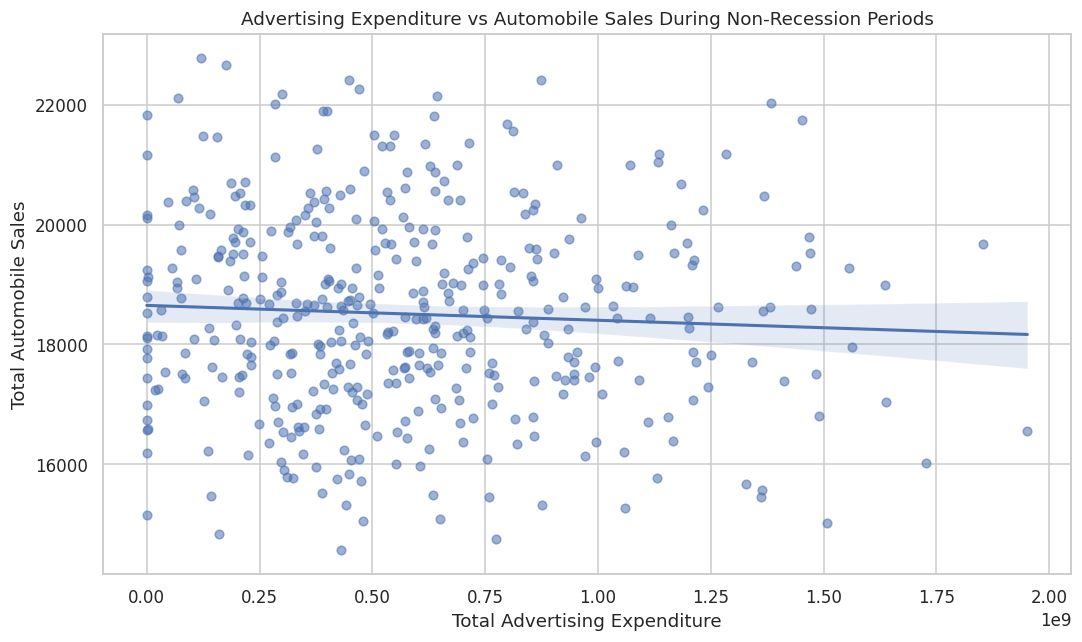

In [4]:
non_rec_data = df[df["Recession"] == 0].copy()
non_rec_monthly = (
    non_rec_data.groupby(["Year", "Month"], as_index=False, observed=True)
    .agg(
        Advertising_Expenditure=("Advertising_Expenditure", "sum"),
        Automobile_Sales=("Automobile_Sales", "sum"),
    )
    .dropna(subset=["Advertising_Expenditure", "Automobile_Sales"])
)
correlation = non_rec_monthly["Advertising_Expenditure"].corr(non_rec_monthly["Automobile_Sales"])
print(f"Pearson correlation (non-recession monthly totals): {correlation:.3f}")

plt.figure(figsize=(10, 6))
sns.regplot(
    data=non_rec_monthly,
    x="Advertising_Expenditure",
    y="Automobile_Sales",
    scatter_kws={"alpha": 0.55, "s": 32},
    line_kws={"linewidth": 2},
)
plt.xlabel("Total Advertising Expenditure")
plt.ylabel("Total Automobile Sales")
plt.title("Advertising Expenditure vs Automobile Sales During Non-Recession Periods")
plt.tight_layout()
plt.savefig("Advertising_vs_Sales_Non_Recession.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 1.3 — Vehicle-Wise Sales During Recession and Non-Recession Periods

The grouped Seaborn bar chart places `Recession` on the x-axis and groups the bars by `Vehicle_Type`, as required by the assignment's grouped-bar-plot question.

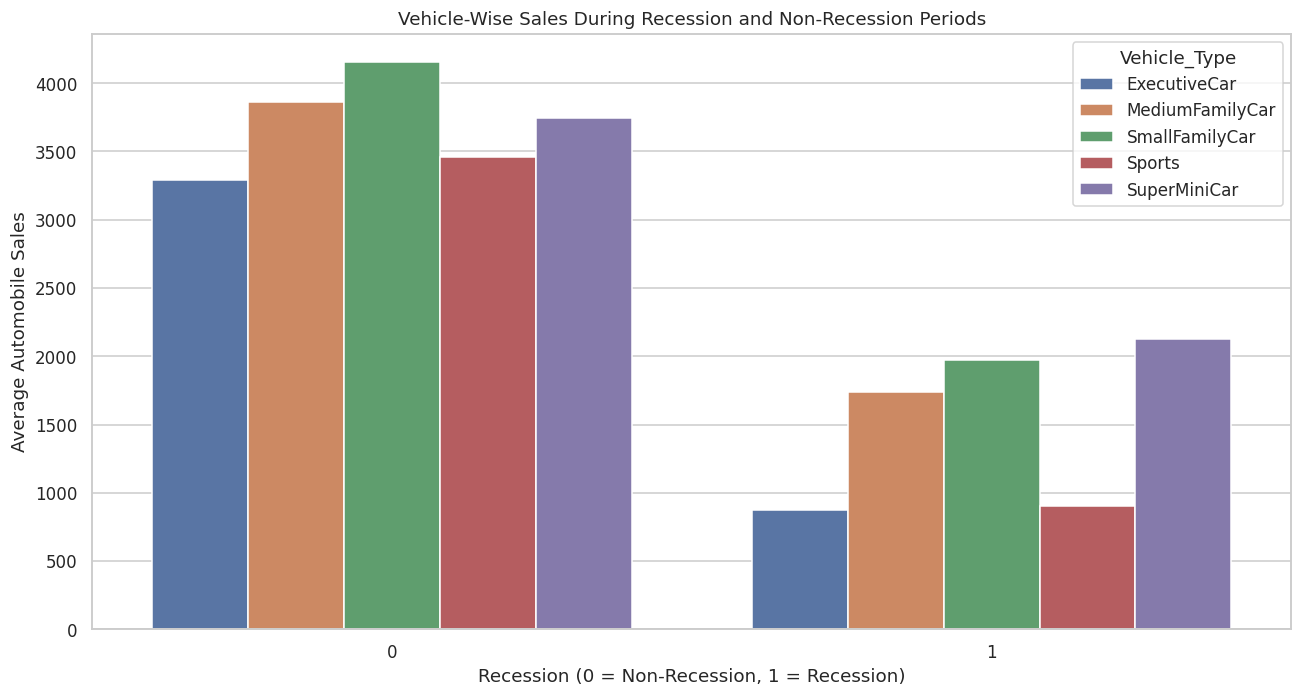

In [5]:
# Use this exact mapping of x, y, hue, and data for the grouped bar chart.
plt.figure(figsize=(12, 6.5))
sns.barplot(x="Recession", y="Automobile_Sales", hue="Vehicle_Type", data=df, errorbar=None)
plt.xlabel("Recession (0 = Non-Recession, 1 = Recession)")
plt.ylabel("Average Automobile Sales")
plt.title("Vehicle-Wise Sales During Recession and Non-Recession Periods")
plt.tight_layout()
plt.savefig("Vehicle_Wise_Sales_Recession_vs_Non_Recession.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 1.4 — GDP Variations During Recession and Non-Recession Periods

Two side-by-side line plots compare average GDP by year for recession and non-recession observations.

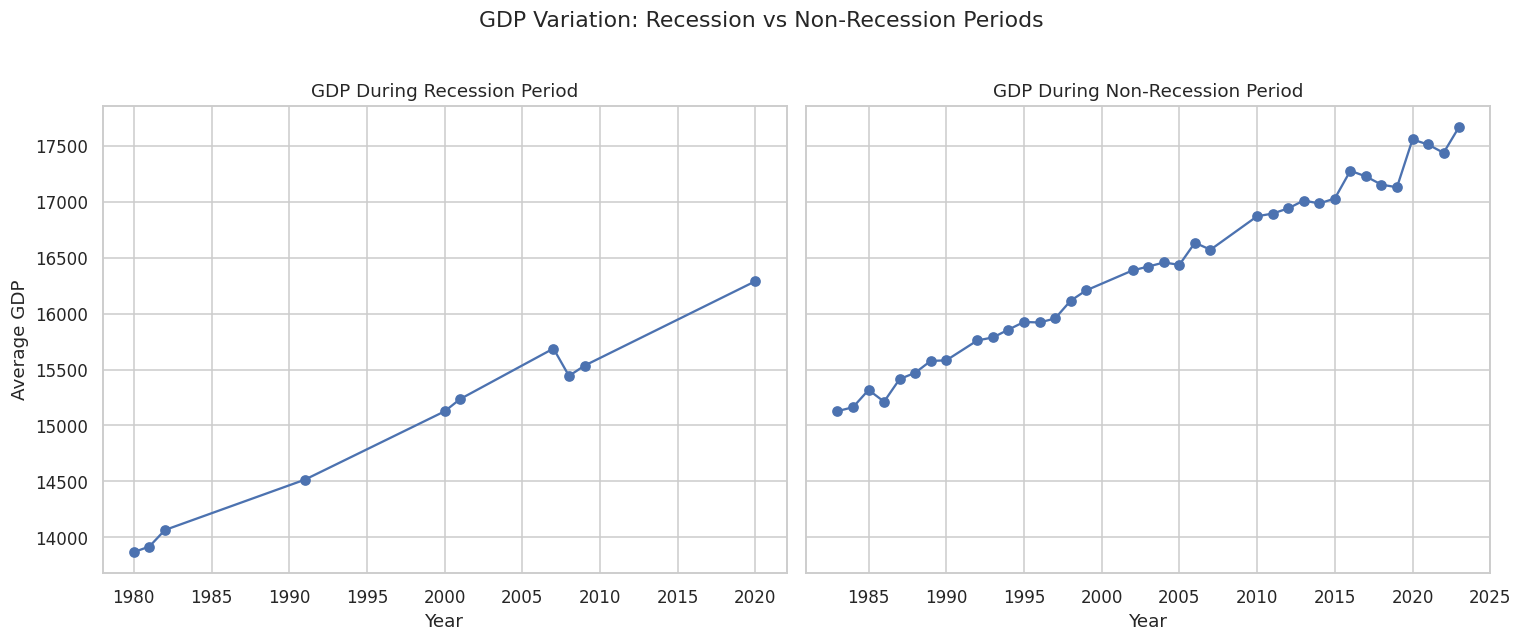

In [6]:
rec_data = df[df["Recession"] == 1].copy()
non_rec_data = df[df["Recession"] == 0].copy()
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 5.7), sharey=True)
rec_data.groupby("Year")["GDP"].mean().plot(ax=ax0, kind="line", marker="o")
ax0.set_title("GDP During Recession Period")
ax0.set_xlabel("Year")
ax0.set_ylabel("Average GDP")
non_rec_data.groupby("Year")["GDP"].mean().plot(ax=ax1, kind="line", marker="o")
ax1.set_title("GDP During Non-Recession Period")
ax1.set_xlabel("Year")
ax1.set_ylabel("Average GDP")
fig.suptitle("GDP Variation: Recession vs Non-Recession Periods", y=1.02)
plt.tight_layout()
plt.savefig("Subplot.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 1.5 — Bubble Plot: Seasonality Impact on Automobile Sales

The bubble size is mapped to `Seasonality_Weight`, and the month axis is ordered from January through December. The plot uses non-recession observations, consistent with the supplied lab workflow.

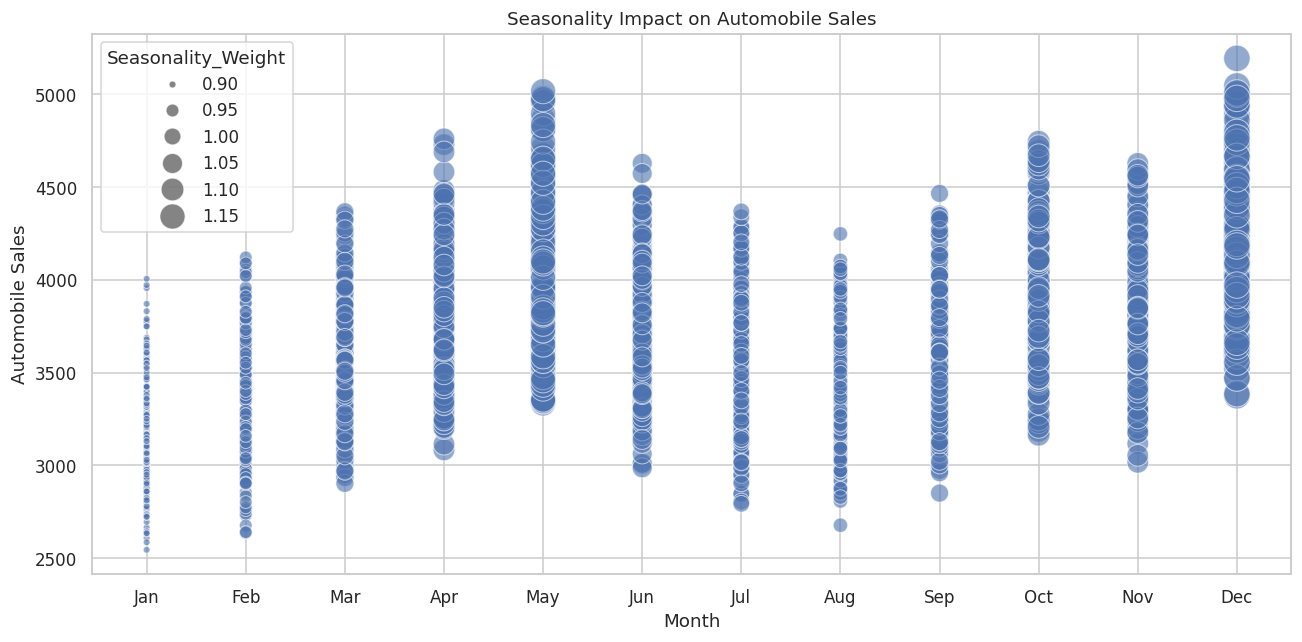

In [7]:
non_rec_data = df[df["Recession"] == 0].copy()
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=non_rec_data,
    x="Month",
    y="Automobile_Sales",
    size="Seasonality_Weight",
    sizes=(20, 300),
    alpha=0.6,
    legend="brief",
)
plt.xlabel("Month")
plt.ylabel("Automobile Sales")
plt.title("Seasonality Impact on Automobile Sales")
plt.tight_layout()
plt.savefig("Bubble.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 1.6 — Relationship Between Vehicle Price and Automobile Sales During Recession

A Matplotlib scatter plot shows the relationship between the `Price` and `Automobile_Sales` values in recession observations.

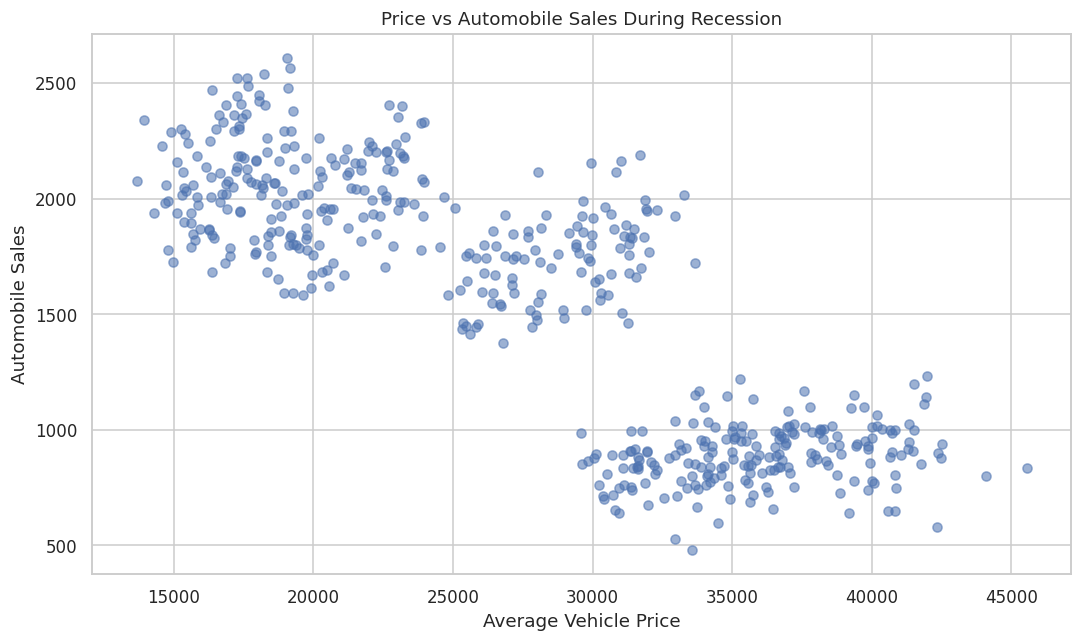

In [8]:
rec_data = df[df["Recession"] == 1].copy()
plt.figure(figsize=(10, 6))
plt.scatter(rec_data["Price"], rec_data["Automobile_Sales"], alpha=0.55)
plt.xlabel("Average Vehicle Price")
plt.ylabel("Automobile Sales")
plt.title("Price vs Automobile Sales During Recession")
plt.tight_layout()
plt.savefig("Scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 1.7 — Advertising Expenditure Distribution: Recession vs Non-Recession

The pie chart compares total advertising expenditure across the two economic conditions.

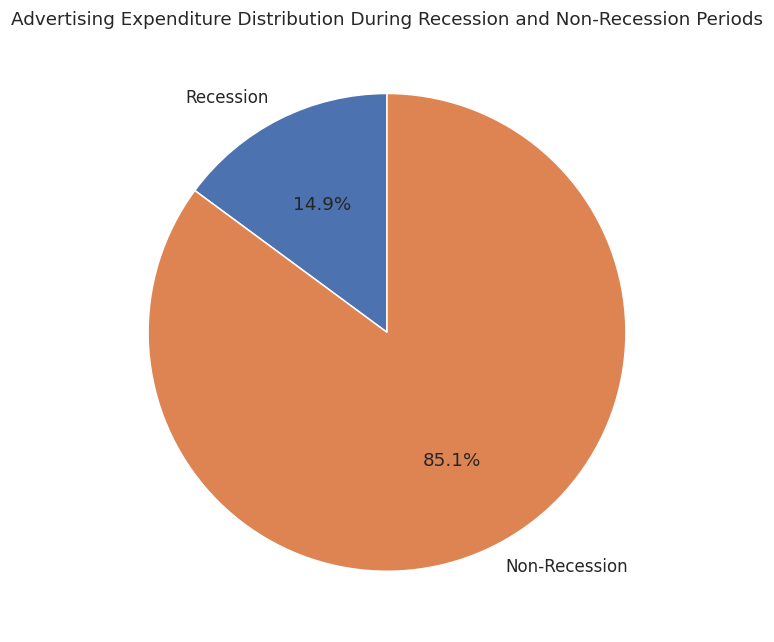

In [9]:
rec_advertising = df.loc[df["Recession"] == 1, "Advertising_Expenditure"].sum()
non_rec_advertising = df.loc[df["Recession"] == 0, "Advertising_Expenditure"].sum()
plt.figure(figsize=(8, 6))
plt.pie(
    [rec_advertising, non_rec_advertising],
    labels=["Recession", "Non-Recession"],
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Advertising Expenditure Distribution During Recession and Non-Recession Periods")
plt.tight_layout()
plt.savefig("Pie_1.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 1.8 — Total Advertisement Expenditure for Each Vehicle Type During Recession

This pie chart groups recession-period advertising expenditure by `Vehicle_Type`. The labels and title explicitly refer to advertising expenditure rather than vehicle sales.

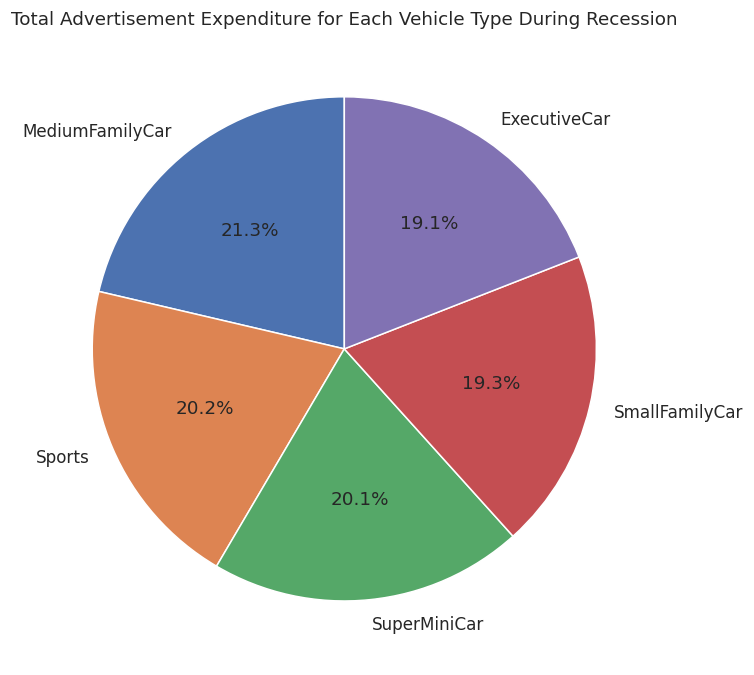

In [10]:
Rdata = df[df["Recession"] == 1].copy()
VT_expenditure = Rdata.groupby("Vehicle_Type")["Advertising_Expenditure"].sum().sort_values(ascending=False)
plt.figure(figsize=(8.5, 6.3))
plt.pie(VT_expenditure.values, labels=VT_expenditure.index, autopct="%1.1f%%", startangle=90)
plt.title("Total Advertisement Expenditure for Each Vehicle Type During Recession")
plt.tight_layout()
plt.savefig("Pie_2.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 1.9 — Effect of Unemployment Rate on Vehicle Type and Automobile Sales During Recession

The line plot uses the recession subset and distinguishes vehicle categories by hue. The unemployment variable name is normalized during data loading for compatibility with the dataset variants used in the course material.

/tmp/ipykernel_940/1210700511.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


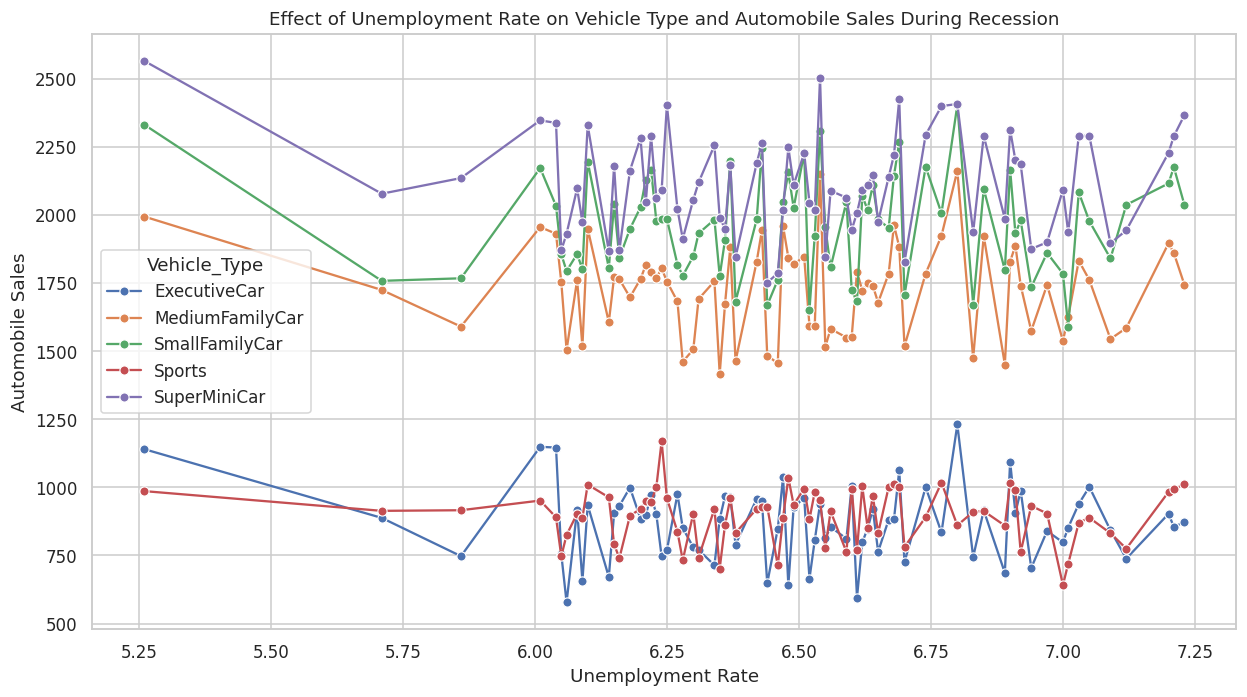

In [11]:
rec_data = df[df["Recession"] == 1].copy()
plt.figure(figsize=(11.5, 6.5))
sns.lineplot(
    data=rec_data,
    x=UNEMPLOYMENT_COL,
    y="Automobile_Sales",
    hue="Vehicle_Type",
    marker="o",
    ci=None,
)
plt.xlabel("Unemployment Rate")
plt.ylabel("Automobile Sales")
plt.title("Effect of Unemployment Rate on Vehicle Type and Automobile Sales During Recession")
plt.tight_layout()
plt.savefig("LinePlot_Unemployment.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusion

The nine required criteria are represented in the executed charts above: annual sales changes; the non-recession advertising/sales relationship; vehicle-wise recession vs non-recession sales; GDP differences; seasonality bubbles; recession-period price vs sales; advertising expenditure by economic condition; advertising expenditure by vehicle type during recession; and unemployment-rate/sales patterns by vehicle type during recession.

The separate Task 1.2 vehicle-type trend line chart is also included. Chart files are saved alongside this notebook when it is executed.